# Quantum Phase Estimation (QPE)

In this module, you will:
- Understand the **Quantum Phase Estimation (QPE)** algorithm — a key subroutine in Shor's algorithm, quantum chemistry, and many other quantum algorithms.
- Learn the **mathematical foundation**: Hadamard transforms, controlled unitaries, the inverse QFT, and how they combine to extract a phase.
- Build and run the QPE circuit using the QpiAI Quantum SDK — both **manually** with `Circuit` and via the high-level `QuantumPhaseEstimation` class.
- Run experiments on a **simulator** and verify that the measurement outcome reveals the correct phase.

## What is Quantum Phase Estimation?

Let $U$ be a unitary operator and let $|\psi\rangle$ be one of its eigenstates:

$$U |\psi\rangle = e^{2\pi i \,\phi} |\psi\rangle$$

Here, $\phi \in [0, 1)$ is the **phase** we want to estimate.

**The Challenge:** Given oracle access to controlled-$U$ operations, determine $\phi$ to $t$ bits of precision.

- **Classically**, estimating $\phi$ requires exponentially many oracle queries.
- **Quantumly**, QPE finds a $t$-bit approximation of $\phi$ using $O(1)$ rounds of controlled-$U$ calls (though each round applies $U$ up to $2^{t-1}$ times).

**Key Insight:** The algorithm encodes $\phi$ into the *phases* of a quantum state, then uses the **inverse Quantum Fourier Transform ($\text{QFT}^{-1}$)** to decode it into a computational-basis measurement.

## 1. Setup & Authentication

We reuse the same authentication pattern as previous modules: load `API_KEY` from `qcloud.env` and authenticate with `QpiAIQuantumAuth`.

In [ ]:
import os

from dotenv import load_dotenv
from qpiai_quantum import QpiAIQuantumAuth

load_dotenv("./qcloud.env") # This path should point to the env file containing your API key.

QpiAIQuantumAuth.login(os.getenv("API_KEY"))
user_info = QpiAIQuantumAuth.me()

print(f"✅ Authenticated successfully as: {user_info.get('name', 'User')} ({user_info.get('email', '')})")

## 2. SDK Primitives Used (This Module)

- `QuantumPhaseEstimation` — high-level algorithm class that builds and runs the QPE circuit.
- `Circuit` — low-level circuit construction API (for manual QPE circuit building).
- `QFT` — utility class providing `apply_inverse_qft_to_circuit()` for the inverse QFT step.
- **Gates:** `h` (Hadamard), `x` (Pauli-X), `cp` (controlled phase), `cz` (controlled-Z), `cx` (CNOT).
- **Circuit utilities:** `show()`, `list_gates()`.
- **Execution:** `QuantumPhaseEstimation.run(shots=..., device_name="QpiAI-QSV-Local") (Note: `experiment_name` is optional and only required for cloud executions)`.
- **Results:** `result.get_counts()`, `result.get_probabilities()`, `result.plot()`.

We will first review the theory, then build the circuit **manually** to understand each stage, and finally use the high-level class for convenience.

## 3. Theory: How QPE Works

The QPE circuit uses two registers:

- A **precision register** (also called the control or counting register) of $t$ qubits, initialized to $|0\rangle^{\otimes t}$.
- A **target register**, initialized to the eigenstate $|\psi\rangle$.

### Stage 1 — Superposition on Precision Register

Apply Hadamard gates to every qubit in the precision register:

$$|0\rangle^{\otimes t} \xrightarrow{H^{\otimes t}} \frac{1}{\sqrt{2^t}} \sum_{k=0}^{2^t - 1} |k\rangle$$

### Stage 2 — Eigenstate Preparation

Prepare $|\psi\rangle$ in the target register. For standard single-qubit unitaries like $T$, $S$, or $Z$, the eigenstate is $|1\rangle$.

### Stage 3 — Controlled Unitary Operations

For each precision qubit $j \in \{0, 1, \dots, t-1\}$, apply the controlled power $\text{C-}U^{2^{t-1-j}}$ with qubit $j$ as control and the target register as target. We use powers of $2^{t-1-j}$ because the SDK uses a little-endian convention where qubit 0 represents the Most Significant Bit (MSB):\n

$$\frac{1}{\sqrt{2^t}} \sum_{k=0}^{2^t - 1} |k\rangle \otimes |\psi\rangle \;\longrightarrow\; \frac{1}{\sqrt{2^t}} \sum_{k=0}^{2^t - 1} e^{2\pi i \,k \phi} |k\rangle \otimes |\psi\rangle$$

The phase $\phi$ is now encoded in the amplitudes of the precision register.

### Stage 4 — Inverse QFT

Apply $\text{QFT}^{-1}$ to the precision register. This converts the phase-encoded state into the computational-basis representation of $\phi$:

$$|\tilde{\phi}\rangle \approx |\phi_1 \phi_2 \dots \phi_t \rangle$$

where:

$$\phi \approx 0.\phi_1 \phi_2 \dots \phi_t$$

is the $t$-bit binary fraction approximation of the phase.

### Stage 5 — Measurement

Measure the precision register. The outcome is an integer $m \in \{0, 1, \dots, 2^t - 1\}$, and the estimated phase is:

$$\hat{\phi} = \frac{m}{2^t}$$

With high probability, $\hat{\phi}$ is a good approximation of the true phase $\phi$. If $\phi$ is exactly representable in $t$ bits, the result is deterministic.

### Summary

$$U |\psi\rangle = e^{2\pi i \,\phi} |\psi\rangle \quad \longrightarrow \quad \hat{\phi} \approx \phi$$

using:

1. Hadamard gates on the precision register
2. Controlled-$U^{2^j}$ operations
3. Inverse QFT
4. Measurement

## 4. Example: Estimating the Phase of the S Gate

### Why the S Gate?

The $S$ gate (also called the phase gate or $\sqrt{Z}$) applies a phase shift of $\pi/2$ to the $|1\rangle$ state:

$$S = \begin{pmatrix} 1 & 0 \\ 0 & i \end{pmatrix}$$

Its eigenvalue equation on $|1\rangle$ is:

$$S|1\rangle = i\,|1\rangle = e^{i\pi/2}|1\rangle = e^{2\pi i \cdot (1/4)}|1\rangle$$

So the phase is $\phi = 1/4 = 0.25$. In binary, $0.25 = 0.01_2$, which requires only **2 precision bits** to represent exactly. With 4 precision qubits we have far more than enough, so the result should be **deterministic**.

**Expected measurement outcome:**

$$m = \phi \times 2^t = 0.25 \times 16 = 4 \quad \Longrightarrow \quad \text{bitstring } \texttt{0100}$$

We will also test with the **T gate** ($\phi = 1/8$) and the **Z gate** ($\phi = 1/2$).

| Gate | Eigenvalue on $\vert 1\rangle$ | Phase $\phi$ | Binary | Expected $m$ (4 precision qubits) | Bitstring |
|:---:|:---:|:---:|:---:|:---:|:---:|
| $T$ | $e^{i\pi/4}$ | $1/8$ | $0.001_2$ | $2$ | `0010` |
| $S$ | $e^{i\pi/2}$ | $1/4$ | $0.01_2$ | $4$ | `0100` |
| $Z$ | $e^{i\pi}$ | $1/2$ | $0.1_2$ | $8$ | `1000` |

## 5. Code: Building the QPE Circuit

The QPE circuit has **five stages**:

1. **Superposition:** Apply $H$ to all $t$ precision qubits.
2. **Eigenstate preparation:** Apply $X$ to the target qubit to prepare $|1\rangle$.
3. **Controlled unitaries:** Apply controlled-$U^{2^{t-1-j}}$ for $j = 0, 1, \dots, t-1$.
4. **Inverse QFT:** Apply $\text{QFT}^{-1}$ to the precision register.
5. **Measurement:** Measure the precision register.

### 5a. Manual Construction with `Circuit`

Let's build the QPE circuit for the **S gate** with **4 precision qubits** and **1 eigenstate qubit** (5 qubits total).

=== Manual QPE Circuit (S gate, 4 precision qubits) ===


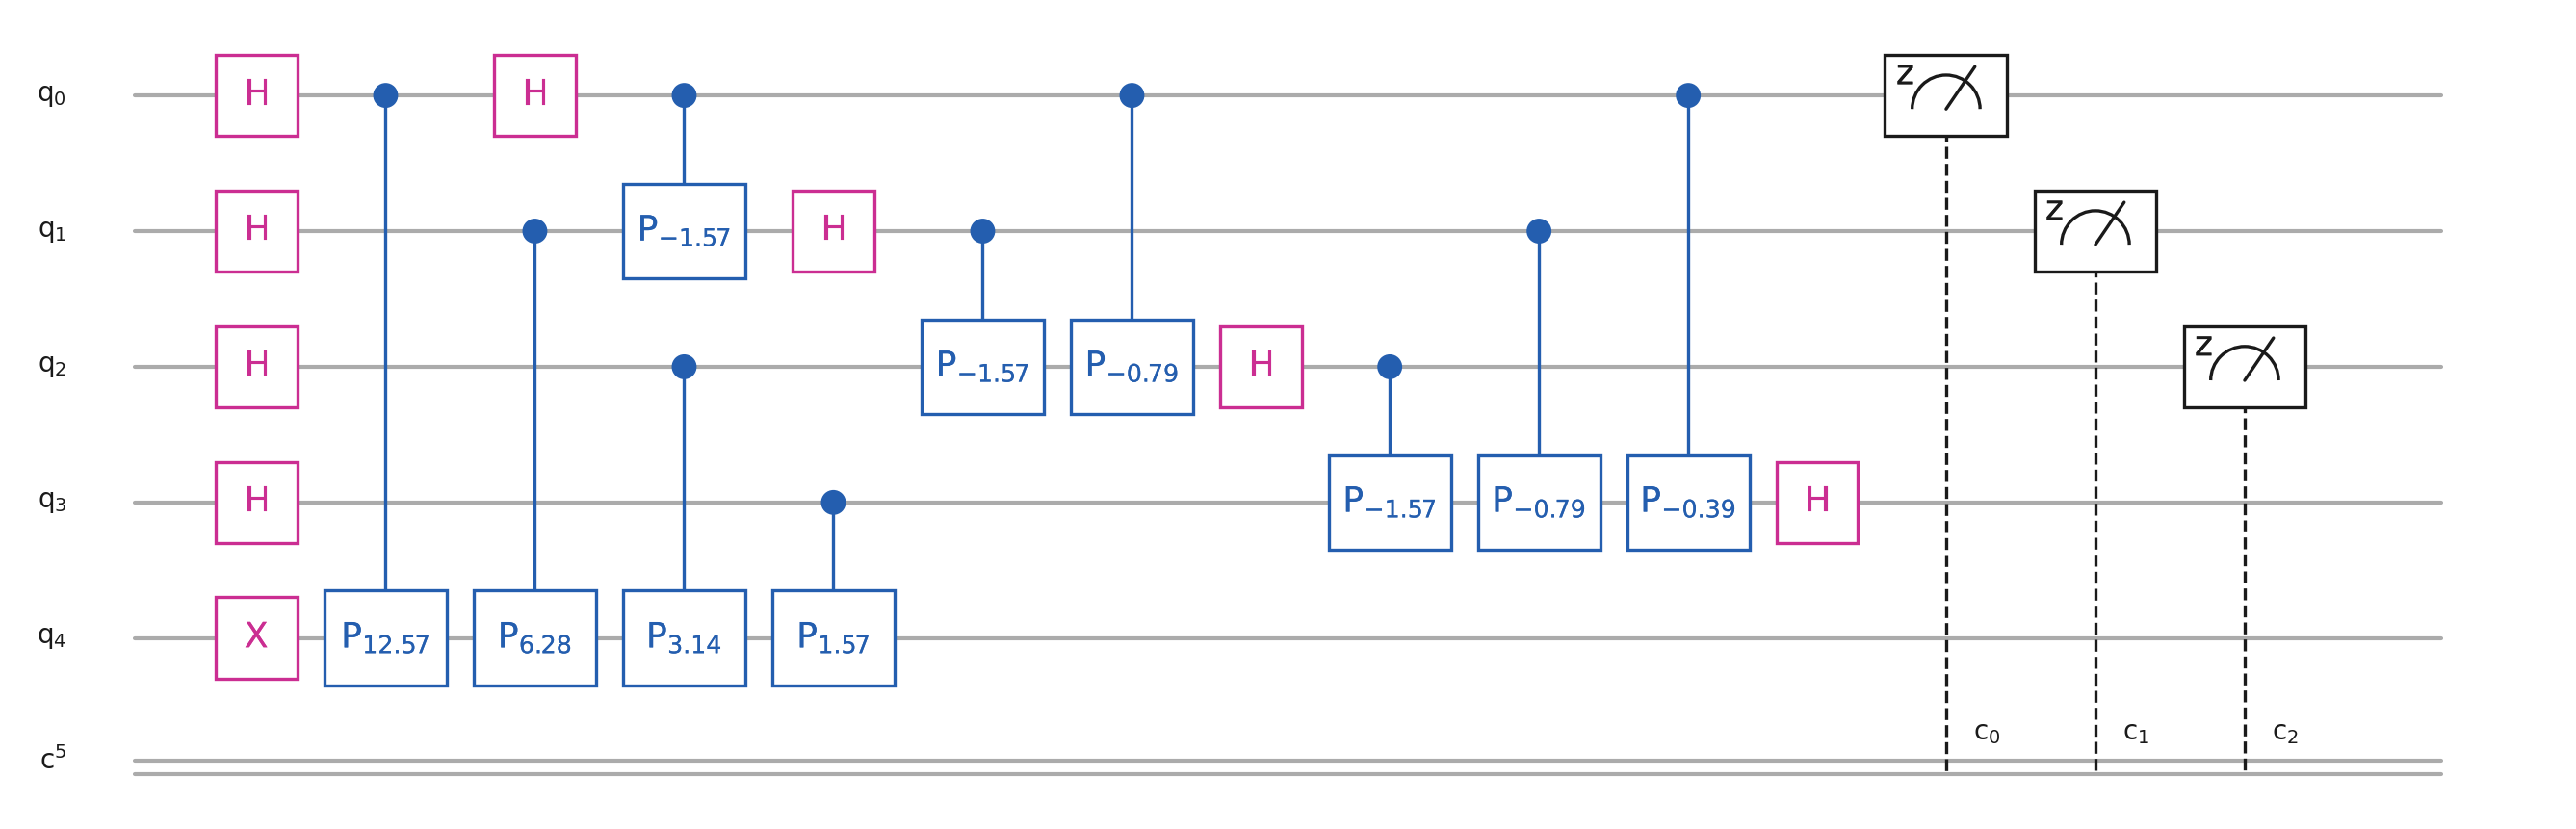

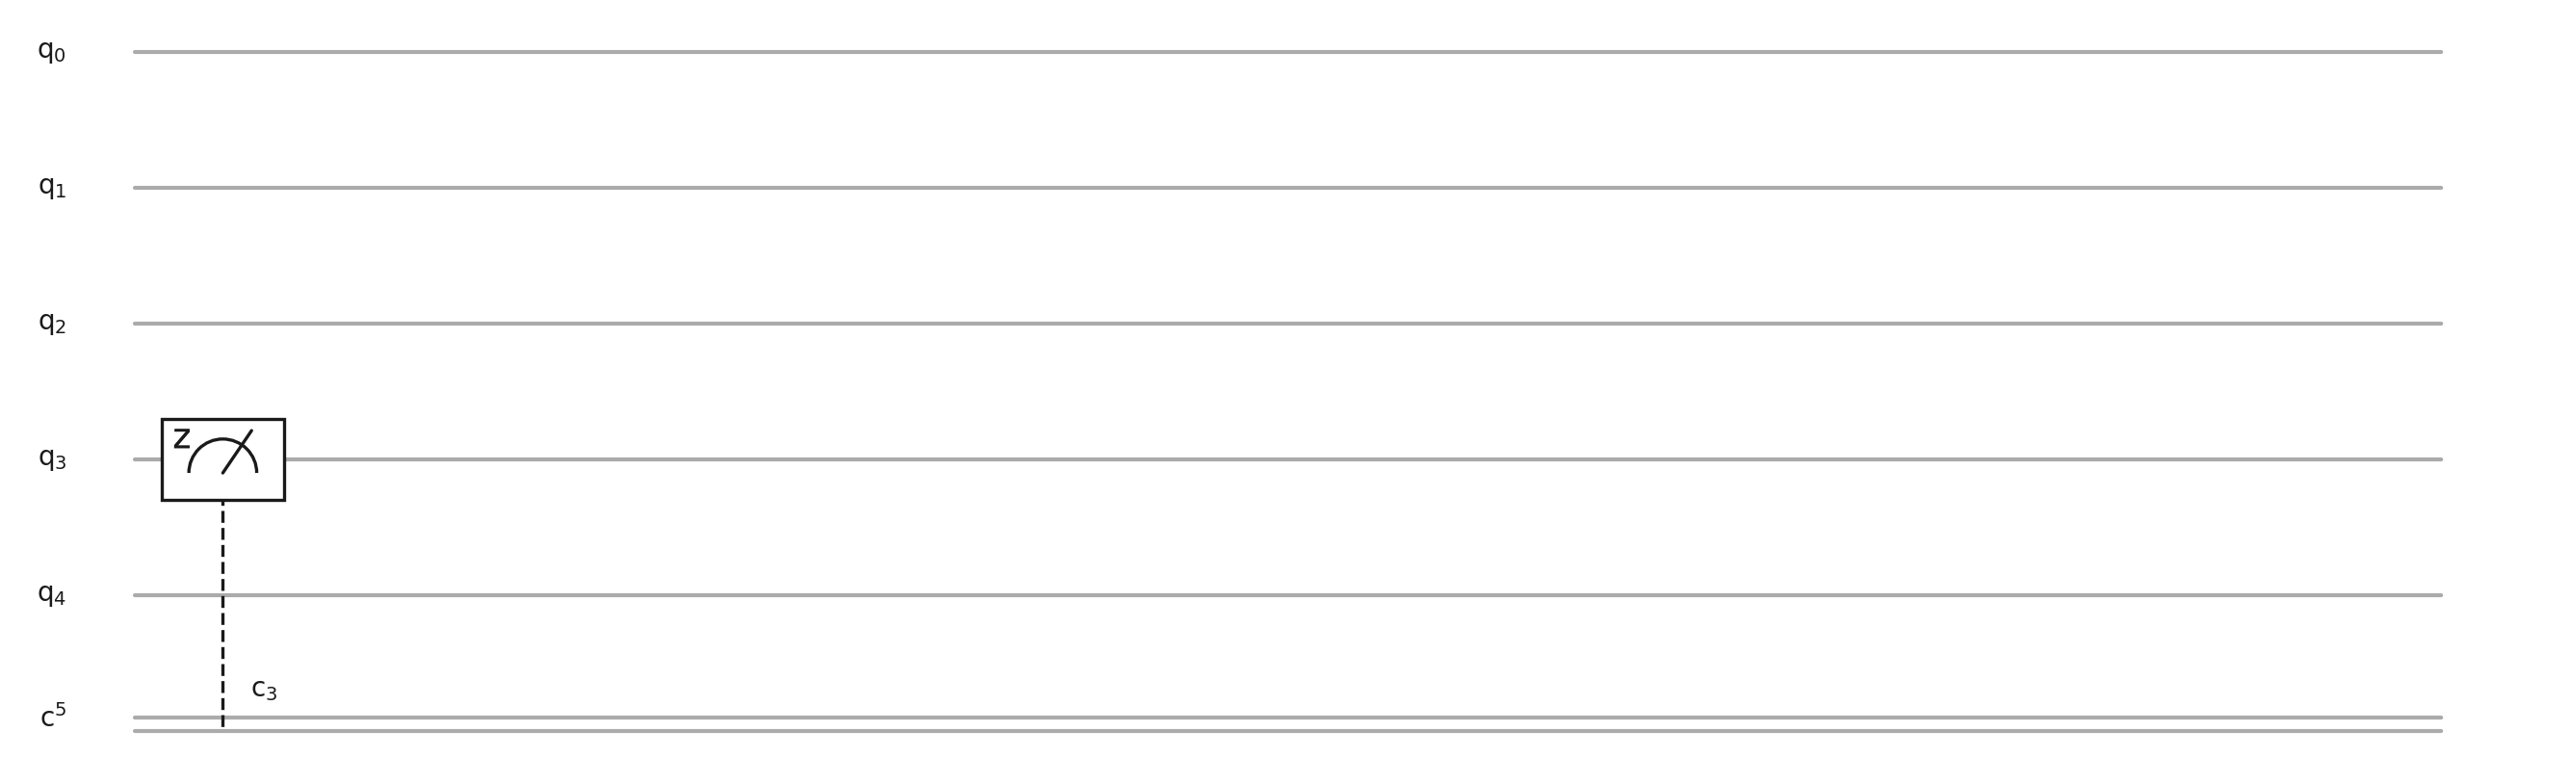

Gate stats: {'total_operations': 23, 'total_gates': 19, 'single_qubit_gates': 9, 'two_qubit_gates': 10, 'multi_qubit_gates': 0, 'clifford_gates': 9, 'non_clifford_gates': 10, 'parametric_gates': 10, 'measurements': 4, 'barriers': 0, 'gate_counts': {'H': 8, 'X': 1, 'CP': 10, 'MEASURE': 4}}


In [2]:
import math
from qpiai_quantum import Circuit
from qpiai_quantum.algorithms.qft import QFT

t = 4  # number of precision qubits
n = 1  # number of eigenstate qubits
total_qubits = t + n  # 5 qubits

qc = Circuit(total_qubits, t)  # 5 qubits, 4 classical bits (measure precision register only)

# ── Stage 1: Create superposition on precision register ──
for i in range(t):
    qc.h(i)

# ── Stage 2: Prepare eigenstate |1⟩ on target qubit ──
target = t  # qubit index 4
qc.x(target)

# ── Stage 3: Apply controlled unitaries for the S gate ──
# QFT uses little-endian ordering (qubit 0 = MSB), so we assign powers 2^(t-1-j)
for j in range(t):
    power = 2 ** (t - 1 - j)
    angle = power * (math.pi / 2)  # S-gate phase = π/2
    qc.cp(j, target, angle)

# ── Stage 4: Apply inverse QFT to precision register ──
QFT.apply_inverse_qft_to_circuit(qc, 0, t)

# ── Stage 5: Measure precision register ──
for i in range(t):
    qc.measure(i, i)

print("=== Manual QPE Circuit (S gate, 4 precision qubits) ===")
qc.show()
print("Gate stats:", qc.list_gates())

### 5b. High-Level Construction with `QuantumPhaseEstimation`

The SDK provides a convenient `QuantumPhaseEstimation` class that wraps all five stages above.

**Constructor parameters:**

| Parameter | Description |
|:---|:---|
| `precision_qubits` | Number of qubits in the precision (counting) register — controls the accuracy of the phase estimate. |
| `eigenstate_qubits` | Number of qubits in the target (eigenstate) register. For single-qubit gates this is 1. |

Description: Quantum Phase Estimation with 4-bit precision

=== QPE Circuit (high-level, S gate) ===


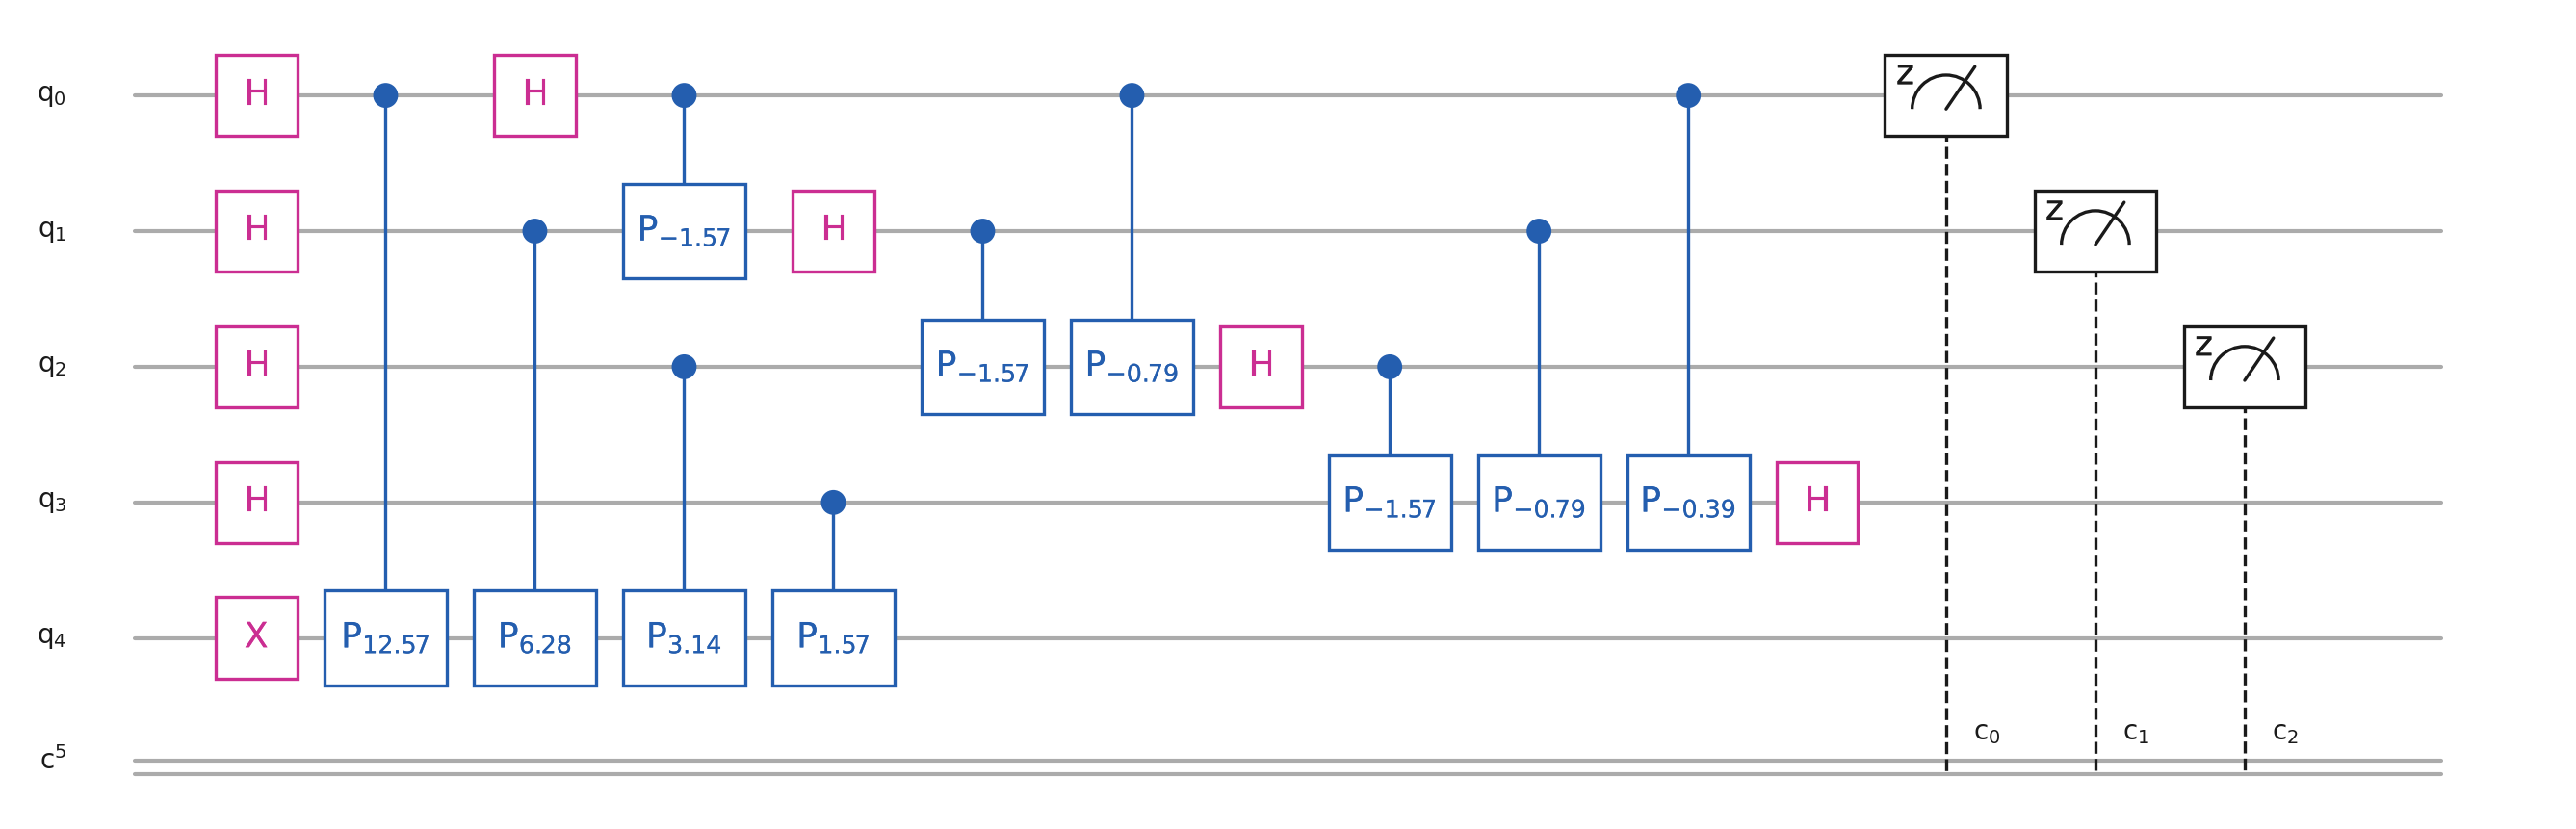

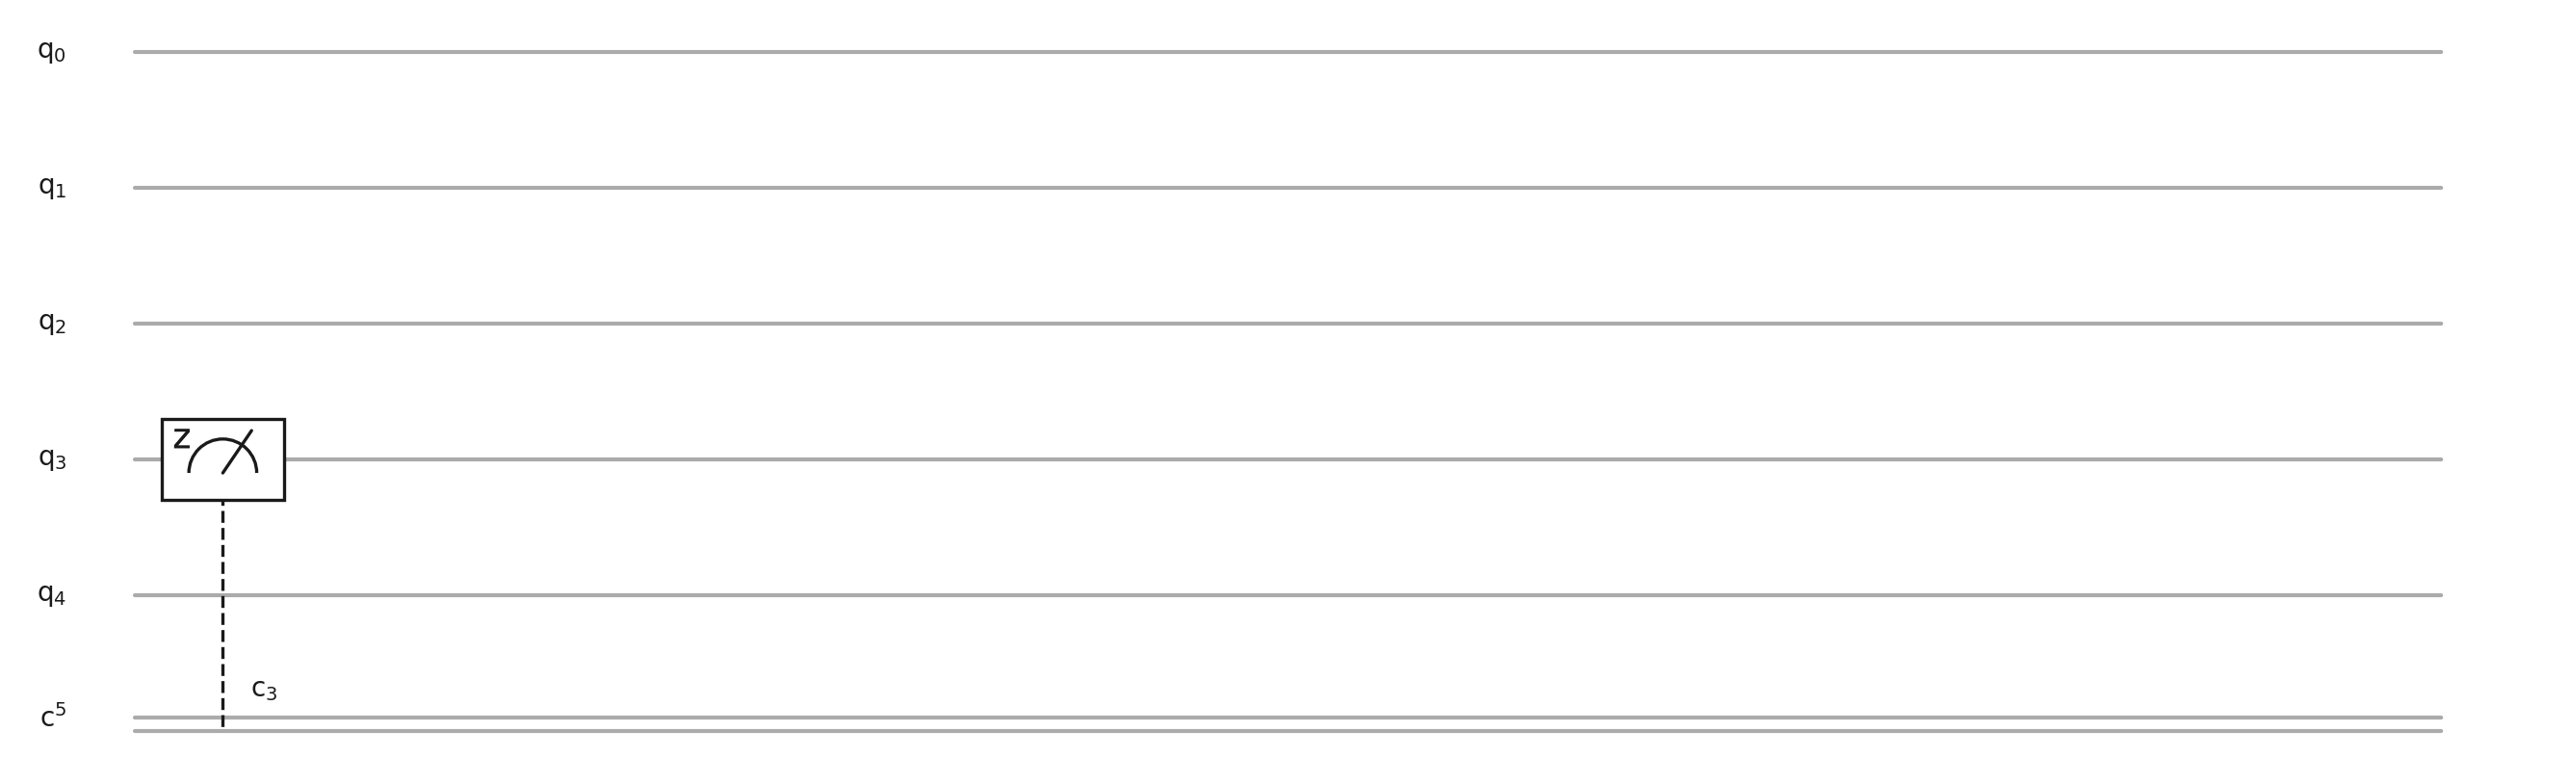

Gate stats: {'total_operations': 23, 'total_gates': 19, 'single_qubit_gates': 9, 'two_qubit_gates': 10, 'multi_qubit_gates': 0, 'clifford_gates': 9, 'non_clifford_gates': 10, 'parametric_gates': 10, 'measurements': 4, 'barriers': 0, 'gate_counts': {'H': 8, 'X': 1, 'CP': 10, 'MEASURE': 4}}


In [3]:
from qpiai_quantum.algorithms import QuantumPhaseEstimation

# Create QPE instance: 4 precision qubits, 1 eigenstate qubit
qpe = QuantumPhaseEstimation(precision_qubits=4, eigenstate_qubits=1)
print("Description:", qpe.description)

# Build the circuit for the S gate
circuit = qpe.build_circuit(unitary='S')
print("\n=== QPE Circuit (high-level, S gate) ===")
circuit.show()
print("Gate stats:", circuit.list_gates())

### 5c. Theoretical Result

Before running, let's confirm what the algorithm **should** produce:

In [4]:
# Theoretical phase for the S gate
theoretical_phase = qpe.get_theoretical_phase('S')
print(f"Theoretical phase φ = {theoretical_phase}")
print(f"Expected measurement integer m = φ × 2^t = {theoretical_phase} × {2**4} = {int(theoretical_phase * 2**4)}")
print(f"Expected bitstring: {format(int(theoretical_phase * 2**4), f'0{4}b')}")

Theoretical phase φ = 0.25
Expected measurement integer m = φ × 2^t = 0.25 × 16 = 4
Expected bitstring: 0100


## 6. Experiment: Simulate and Verify

We will now run QPE for **three different unitary operators** ($T$, $S$, $Z$) and verify that the estimated phase matches the theoretical value.

> **Simulator default:** `device_name="QpiAI-QSV-Local"`. To use a QPU, change `device_name` to `"QpiAI-Indus-1"` and configure an experiment with the same name in the QpiAI web UI.

> **Note:** The `experiment_name` parameter is omitted here because it is only required for cloud executions (e.g., on QCloud simulators or Indus QPU). For local simulation (`QpiAI-QSV-Local`), it is not needed.


In [5]:
import math

# Test with T, S, and Z gates
test_unitaries = ['T', 'S', 'Z']
shots = 10_000

results = {}
for gate_name in test_unitaries:
    qpe_inst = QuantumPhaseEstimation(precision_qubits=4, eigenstate_qubits=1)
    qpe_inst.build_circuit(unitary=gate_name)

    theoretical = qpe_inst.get_theoretical_phase(gate_name)
    expected_m = int(theoretical * 2**4)
    expected_bits = format(expected_m, '04b')

    print(f"\n=== Unitary: {gate_name} gate ===")
    print(f"  Theoretical phase φ = {theoretical}")
    print(f"  Expected bitstring:   {expected_bits}  (m = {expected_m})")

    # Note: experiment_name is only required for cloud executions
    res = qpe_inst.run(
        shots=shots,
        device_name="QpiAI-QSV-Local",
    )
    counts = res.get_counts() or {}
    probs = res.get_probabilities() or {}
    results[gate_name] = res

    print(f"  Counts:  {counts}")
    print(f"  Probabilities: {probs}")

    if counts:
        measured_bits = max(counts, key=counts.get)
        measured_m = int(measured_bits, 2)
        estimated_phase = measured_m / (2**4)
        match = "✅ MATCH" if abs(estimated_phase - theoretical) < 1e-9 else "❌ MISMATCH"
        print(f"  Measured bitstring:   {measured_bits}  →  φ̂ = {measured_m}/{2**4} = {estimated_phase}  {match}")


=== Unitary: T gate ===
  Theoretical phase φ = 0.125
  Expected bitstring:   0010  (m = 2)
  Counts:  {'0010': 10000}
  Probabilities: {'0010': 1.0}
  Measured bitstring:   0010  →  φ̂ = 2/16 = 0.125  ✅ MATCH

=== Unitary: S gate ===
  Theoretical phase φ = 0.25
  Expected bitstring:   0100  (m = 4)
  Counts:  {'0100': 10000}
  Probabilities: {'0100': 1.0}
  Measured bitstring:   0100  →  φ̂ = 4/16 = 0.25  ✅ MATCH

=== Unitary: Z gate ===
  Theoretical phase φ = 0.5
  Expected bitstring:   1000  (m = 8)
  Counts:  {'1000': 10000}
  Probabilities: {'1000': 1.0}
  Measured bitstring:   1000  →  φ̂ = 8/16 = 0.5  ✅ MATCH



Plotting histogram for QPE with S gate (4 precision qubits)


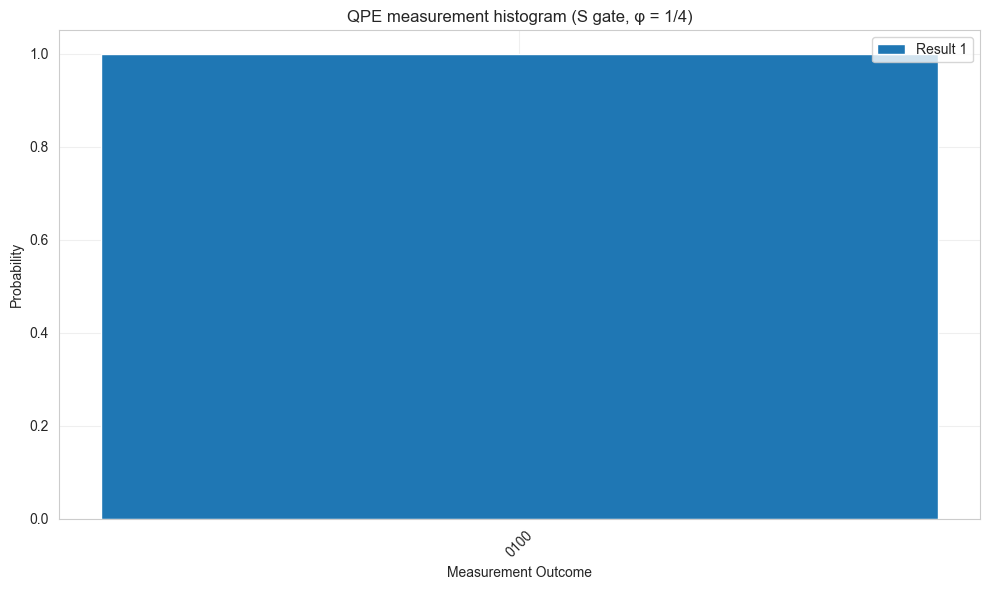

In [6]:
# Visualize the histogram for the S gate
print("\nPlotting histogram for QPE with S gate (4 precision qubits)")
results['S'].plot(title="QPE measurement histogram (S gate, φ = 1/4)")

### Results Interpretation

In the ideal (noiseless) case, you should observe:

- **A single peak** at the bitstring corresponding to $m = \phi \times 2^t$ with **100% probability**.
- **No other outcomes** appear in the histogram.

**How to read the result:**
- The measured bitstring is the binary representation of the integer $m$.
- The estimated phase is $\hat{\phi} = m \,/\, 2^t$.
- For the $S$ gate with 4 precision qubits: $m = 4$, bitstring = `0100`, and $\hat{\phi} = 4/16 = 0.25$ — exactly the true phase.

**What if $\phi$ is not exactly representable?**

If $\phi$ cannot be written as $m/2^t$ for integer $m$, the measurement outcome will be probabilistically distributed around the two nearest representable values. Adding more precision qubits (larger $t$) improves accuracy.

**On a noisy QPU:** The correct bitstring still dominates, but noise may introduce small contributions from other outcomes.

## 7. Exercises

**Beginner:**

1. Run QPE with the $T$ gate and verify $\hat{\phi} = 1/8$. How many precision qubits are needed for an exact result?
2. Run QPE with the $Z$ gate. What bitstring do you expect? Verify.

**Intermediate:**

3. Build the QPE circuit manually (using `Circuit`) for the $T$ gate with 3 precision qubits and display it with `show()`. Identify each controlled-$U^{2^j}$ operation.
4. What happens when you use only 1 or 2 precision qubits for the $T$ gate? Run the experiment and explain the measurement distribution.

**Advanced:**

5. Suppose $\phi = 1/3$. This phase is **not** exactly representable in binary. Run QPE with increasing numbers of precision qubits (3, 5, 8) and observe how the measurement distribution sharpens around the true phase.
6. QPE is the core subroutine in **Shor's algorithm** (for period finding) and in **quantum chemistry** (for estimating molecular ground-state energies). Research and explain how QPE is used in one of these applications.

## 8. Key Takeaways

- **Quantum Phase Estimation** extracts the phase $\phi$ from $U|\psi\rangle = e^{2\pi i\,\phi}|\psi\rangle$ by encoding it into a computational-basis state.
- The algorithm uses **three key ingredients**: Hadamard gates (create superposition), controlled-$U^{2^j}$ operations (encode phase), and the **inverse QFT** (decode phase).
- With $t$ precision qubits, the algorithm estimates $\phi$ to $t$ bits of accuracy. If $\phi$ is exactly representable in $t$ bits, the result is **deterministic**.
- The QpiAI SDK provides both a **low-level `Circuit` API** for manual construction and a **high-level `QuantumPhaseEstimation` class** with methods like `build_circuit()`, `run()`, `estimate_phase()`, and `get_theoretical_phase()`.
- On the **statevector simulator**, the result is exact. On real hardware, noise may introduce small errors.
- QPE is a fundamental building block for many important quantum algorithms, including **Shor's algorithm** and **quantum chemistry simulations**.

---
**Thank you for learning with QpiAI!**

In [7]:
import qpiai_quantum
print(f"QpiAI Quantum SDK version: {qpiai_quantum.__version__}")

QpiAI Quantum SDK version: 0.1.32
